# 🏎️ Módulo 3 — Pilotagem e Performance do Piloto

Análise dos canais de telemetria relacionados ao comportamento do piloto:
DRS, ângulo de esterço, RPM, e visualização completa de canais.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.makedirs('../cache', exist_ok=True)
fastf1.Cache.enable_cache('../cache')

from funcoes_telemetria import encontrar_ponto_na_pista, analisar_drs, comparar_drs, analisar_rpm

print("Setup concluído!")

Setup concluído!


# Análise do uso do DRS pelo piloto

In [2]:
session = fastf1.get_session(2025, 'Spain', 'Q')
session.load()

russell = session.laps.pick_driver('RUS').pick_fastest()
tel_rus = russell.get_telemetry().add_distance()

# Vamos ver quais valores o canal DRS assume nessa volta
print("Valores únicos no canal DRS:")
print(sorted(tel_rus['DRS'].unique()))
print(f"\nTotal de pontos: {len(tel_rus)}")

Valores únicos no canal DRS:
[np.int64(8), np.int64(12), np.int64(14)]

Total de pontos: 541


In [3]:
print("Distribuição dos valores DRS:")
print(tel_rus['DRS'].value_counts().sort_index())

print(f"\nPorcentagem com DRS aberto (12 ou 14):")
drs_aberto = (tel_rus['DRS'] >= 12).sum()
print(f"{drs_aberto} pontos de {len(tel_rus)} ({drs_aberto/len(tel_rus)*100:.1f}%)")

Distribuição dos valores DRS:
DRS
8     445
12     90
14      6
Name: count, dtype: int64

Porcentagem com DRS aberto (12 ou 14):
96 pontos de 541 (17.7%)


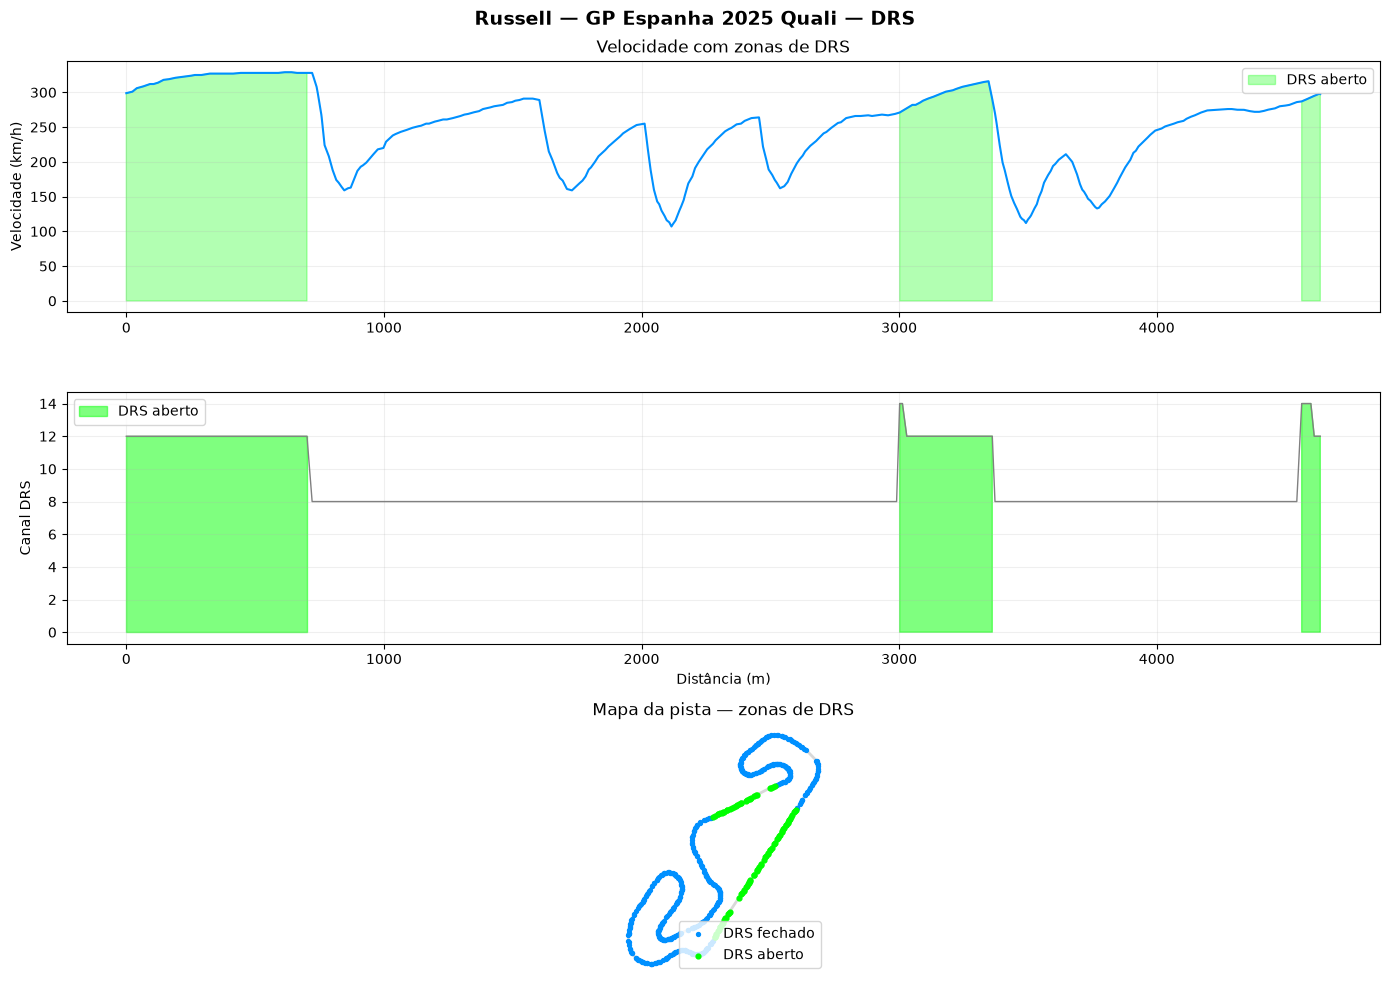

In [4]:
fig = analisar_drs(tel_rus, titulo='Russell — GP Espanha 2025 Quali — DRS')

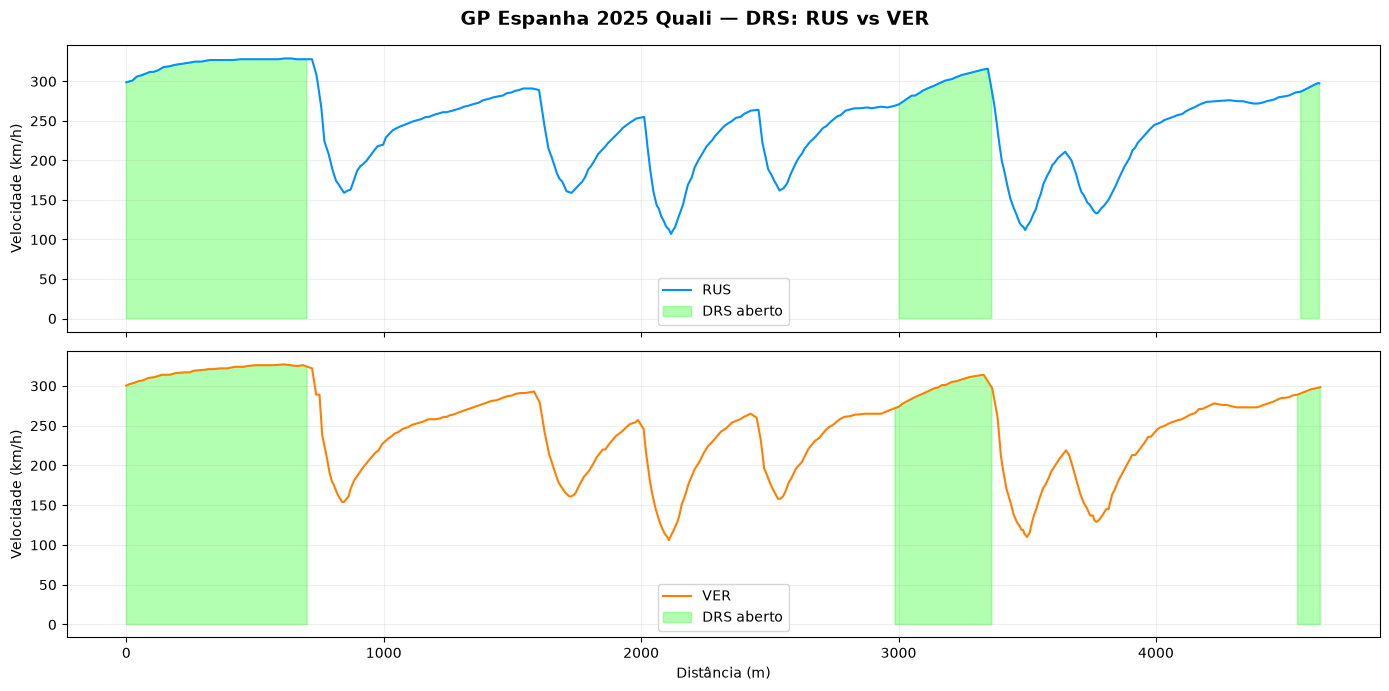

In [5]:
verstappen = session.laps.pick_driver('VER').pick_fastest()
tel_ver = verstappen.get_telemetry().add_distance()

fig = comparar_drs(tel_rus, tel_ver, 'RUS', 'VER', 'GP Espanha 2025 Quali — DRS: RUS vs VER')

# Análise do RPM do motor

In [6]:
print("Canal RPM:")
print(f"Mínimo: {tel_rus['RPM'].min()}")
print(f"Máximo: {tel_rus['RPM'].max()}")
print(f"Média: {tel_rus['RPM'].mean():.0f}")

Canal RPM:
Mínimo: 7979.0
Máximo: 12009.0
Média: 10861


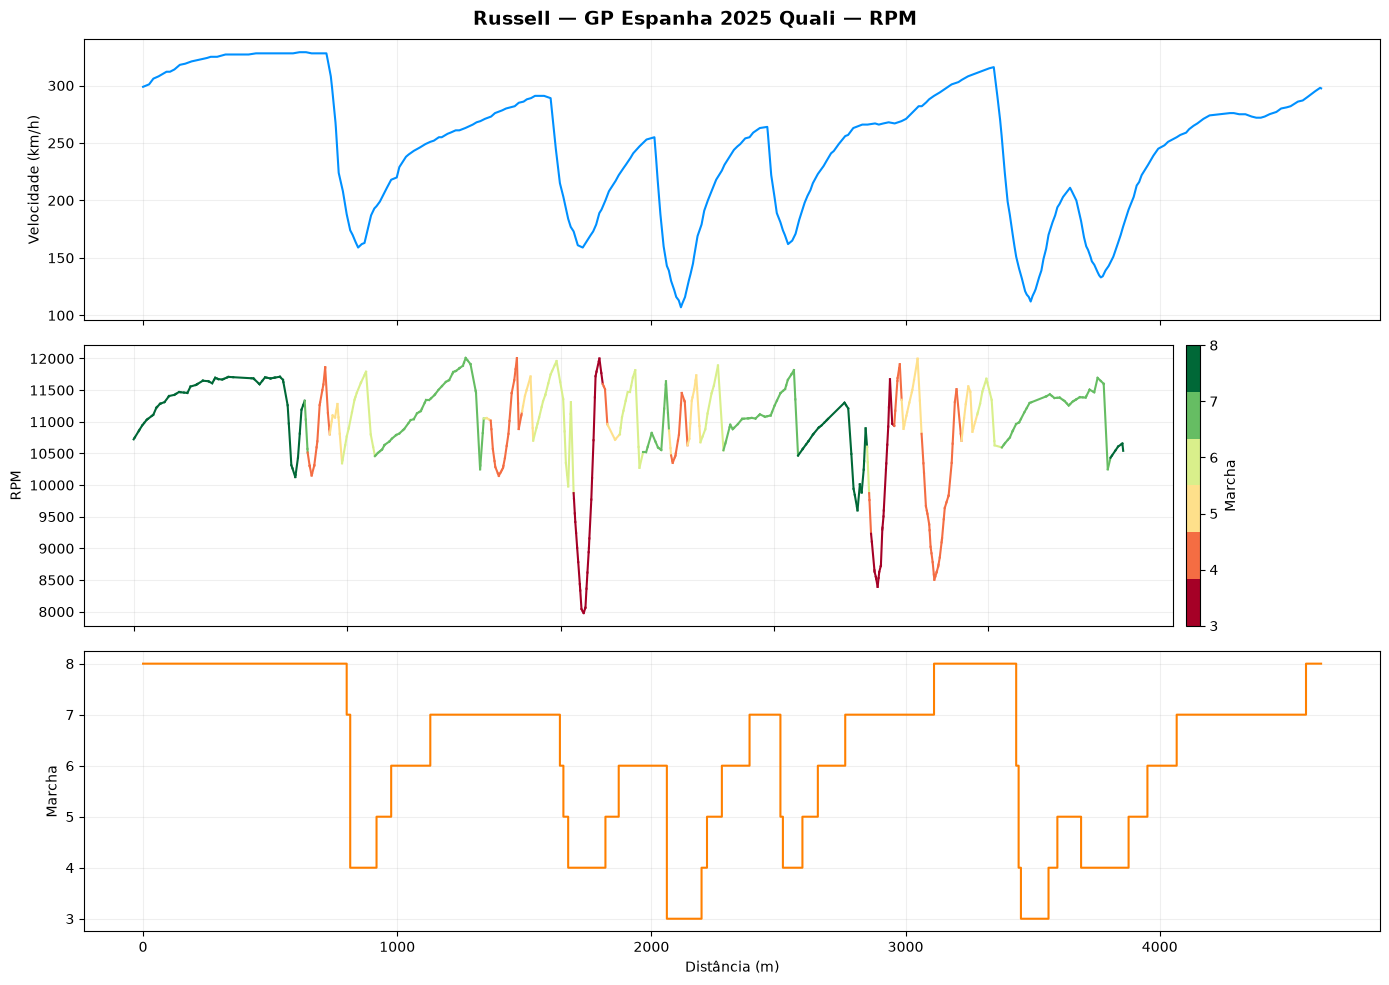

In [8]:
fig = analisar_rpm(tel_rus, titulo='Russell — GP Espanha 2025 Quali — RPM')